In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import matplotlib as mpl
sns.set_style('whitegrid')

random.seed(42)
np.random.seed(42)

In [11]:
spacing = 1.5
scaling = 2
font_scaling = 1.5
width_cm = 8*scaling
height_cm = 5*scaling  # try 7.5–9.5 depending on label length

mpl.rcParams.update({
    "font.size": 10 * font_scaling,
    "axes.titlesize": 10 * font_scaling,
    "axes.labelsize": 10 * font_scaling,
    "xtick.labelsize": 10 * font_scaling,
    "ytick.labelsize": 10 * font_scaling,
})

objects = {
    0: 'can', 
    1: 'bandage', 
    2: 'remote', 
    3: 'bottle', 
    4: 'candle', 
    5: 'box', 
    6: 'book', 
    7: 'cup'
}

# Visualize codes for each condition

## Kolkhorst

In [12]:
target_id = 4

codebook = np.load(f'./condition_1/codebook_obj_{target_id}.npy')

codebook_kolkhorst = []
for code in codebook:
    tmp = []
    for i in code:
        if i == 0:
            tmp += [0] * 250
        elif i == 1:
            tmp += [1] * 100
            tmp += [0] * 150
    codebook_kolkhorst.append(tmp)
codebook_kolkhorst = np.array(codebook_kolkhorst)

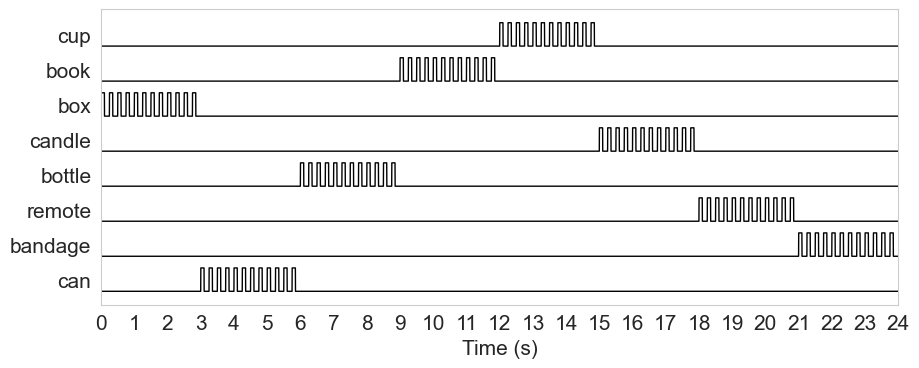

In [13]:
fig, ax = plt.subplots(figsize=(width_cm/2.54 * 1.5, height_cm/2.54))

for i, code in enumerate(codebook_kolkhorst):
    xticks = np.arange(len(code)) / 1000
    ax.plot(xticks, code + i * spacing, color="black", linewidth=1)

# ax.set_title("ERP stimulation sequences.")
ax.set_xlabel("Time (s)")
ax.set_xlim(0, 24)
ax.set_xticks(np.arange(25))

ax.set_yticks(np.arange(len(codebook_kolkhorst)) * spacing + 0.5)
ax.set_yticklabels(list(objects.values()))

ax.grid()
fig.tight_layout()

fig.savefig("../images/kolkhorst_code.pdf", bbox_inches="tight")
plt.show()

## Fast ERP

In [14]:
codebook = np.load('./condition_2/codebook_obj_0.npy')

codebook_erp = []
for code in codebook:
    tmp = []
    for i in code:
        if i == 0:
            tmp += [0] * 250
        elif i == 1:
            tmp += [1] * 100
            tmp += [0] * 150
    codebook_erp.append(tmp)
codebook_erp = np.array(codebook_erp)

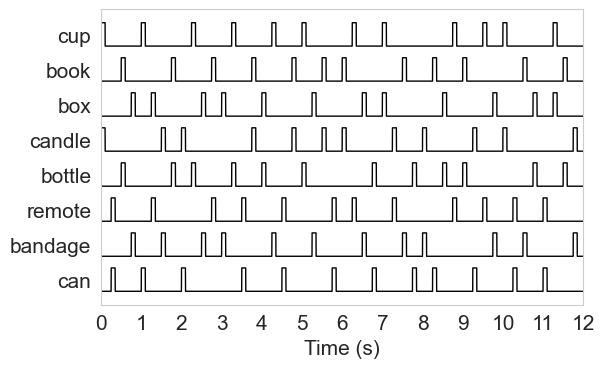

In [15]:
fig, ax = plt.subplots(figsize=(width_cm/2.54, height_cm/2.54))

for i, code in enumerate(codebook_erp):
    xticks = np.arange(len(code)) / 1000
    ax.plot(xticks, code + i * spacing, color="black", linewidth=1)

# ax.set_title("ERP stimulation sequences.")
ax.set_xlabel("Time (s)")
ax.set_xlim(0, 12)
ax.set_xticks(np.arange(13))

ax.set_yticks(np.arange(len(codebook_erp)) * spacing + 0.5)
ax.set_yticklabels(list(objects.values()))

ax.grid()
fig.tight_layout()

fig.savefig("../images/erp_code.pdf", bbox_inches="tight")
plt.show()

## c-VEP

In [16]:
def load_codebook(filepath: str) -> np.ndarray:
    codebook = np.load(filepath).T
    return codebook

def load_codebooks_block_3(fpath: str='./codebooks/condition_3/mseq_61_shift_8.npy', n_reps: int=12, n_objs: int=8) -> np.ndarray:
    """Block 2 aka custom cVEP"""
    codebooks = []
    codebook = load_codebook(fpath)
    # Select 8 codebooks
    codebook = np.vstack([codebook] * n_reps)
    codebooks = np.array([codebook] * n_objs)
    return codebooks

codebook_cvep = load_codebooks_block_3(fpath='./condition_3/mseq_61_shift_8.npy').astype(int)[0]
codebook_cvep = np.repeat(codebook_cvep, 1000 // 60, axis=0).T

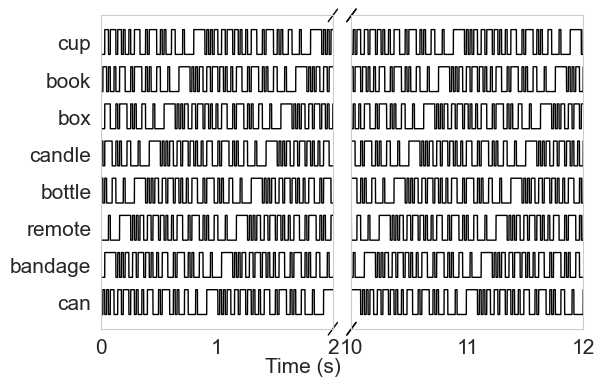

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width_cm/2.54, height_cm/2.54),
                                sharey=True,
                                gridspec_kw={'width_ratios': [1, 1]})

for ax, (xleft, xright) in zip([ax1, ax2], [(0, 2), (10, 12)]):
    for i, code in enumerate(codebook_cvep):
        xticks = np.arange(len(code)) / 1000
        ax.plot(xticks, code + i * spacing, color="black", linewidth=1)
    ax.set_xlim(xleft, xright)
    ax.set_xticks(np.arange(xleft, xright + 1))
    ax.grid()

ax1.set_yticks(np.arange(len(codebook_cvep)) * spacing + 0.5)
ax1.set_yticklabels(list(objects.values()))
# Single centered xlabel for both panels
fig.text(0.5, 0.01, "Time (s)", ha="center", va="bottom")

fig.tight_layout()
fig.subplots_adjust(wspace=0.15, bottom=0.1)  # bottom margin for the label
# Diagonal break marks — slightly larger d to stay visible in wider gap
d = 0.02
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

fig.tight_layout()
fig.subplots_adjust(wspace=0.08)
fig.savefig("../images/cvep_code.pdf", bbox_inches="tight")
plt.show()

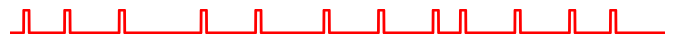

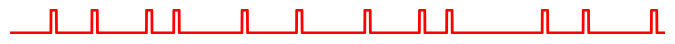

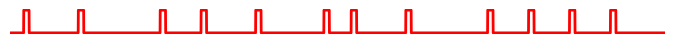

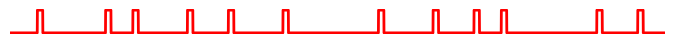

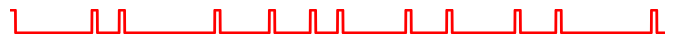

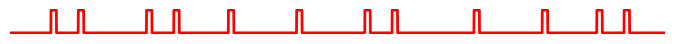

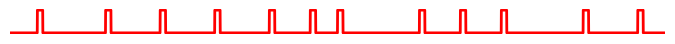

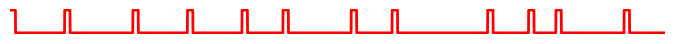

In [18]:
for i, code in enumerate(codebook_erp):
    fig, ax = plt.subplots(figsize=(7, 0.7))
    xticks = np.arange(len(code)) / 1000
    ax.plot(xticks, code + i * spacing, color="red", linewidth=2)
    ax.axis('off')
    ax.set_xlim(0, 12)
    fig.tight_layout()

    fig.savefig(f"../images/fasterp_sequence_{i}.svg", format='svg', bbox_inches="tight", pad_inches=0, transparent=True)
    plt.show()